<a href="https://colab.research.google.com/github/izabayoleonce/Prediction_diabetes_risk/blob/master/MediPredict_Notebook_ML_Ghellai_Izabayo_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 MediPredict — Notebook ML : Prédiction du risque de diabète de type 2

---

**Projet** : Application de sensibilisation au risque de diabète pour la mutuelle fictive SantéCo  
**Dataset** : Pima Indians Diabetes Dataset (768 observations, 8 features, 1 cible binaire)  
**Objectif** : Construire un modèle de classification supervisé, l'évaluer, analyser ses biais et son explicabilité, puis le sauvegarder pour intégration dans une application web Streamlit.

> ⚠️ **Rappel éthique** : Ce modèle est un outil de sensibilisation, jamais un diagnostic médical.

---

## 📦 Installation des dépendances

On commence par installer les librairies nécessaires. Sur Google Colab, la plupart sont déjà disponibles, mais on s'assure que `shap` (pour l'explicabilité) et `joblib` (pour la sauvegarde) sont bien présents.

In [1]:
# Installation des packages nécessaires (exécuter en premier sur Colab)
!pip install shap --quiet
!pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet


### Imports

On importe toutes les librairies dont on aura besoin dans le notebook. L'organisation par catégorie (données, visualisation, ML, explicabilité) rend le code plus lisible.

In [2]:
# ── Manipulation de données ──
import pandas as pd
import numpy as np

# ── Visualisation ──
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ── Explicabilité ──
import shap

# ── Sauvegarde ──
import joblib
import os

# ── Configuration des graphiques ──
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(" Tous les imports sont chargés avec succès.")

 Tous les imports sont chargés avec succès.


---

##  Étape 1 — Chargement et exploration des données

 Cette phase d'exploration permet de :
- Vérifier que les données sont chargées correctement
- Repérer les anomalies et valeurs aberrantes
- Comprendre la distribution de chaque variable
- Identifier le déséquilibre éventuel des classes



### 1.1 — Chargement du dataset

In [3]:
# Charger le dataset
# Sur Colab : uploader le fichier diabetes.csv ou le charger depuis Google Drive
df = pd.read_csv('/content/diabetes.csv')

# Vérification rapide : dimensions du dataset
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nVariable cible : 'Outcome' (0 = non diabétique, 1 = diabétique)")

Dimensions du dataset : 768 lignes × 9 colonnes

Colonnes : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Variable cible : 'Outcome' (0 = non diabétique, 1 = diabétique)


### 1.2 — Aperçu des premières lignes

On affiche les premières lignes pour vérifier visuellement que le chargement s'est bien passé et pour se familiariser avec la structure des données.

In [4]:
# Affichage des 10 premières lignes
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


### 1.3 — Statistiques descriptives

`describe()` nous donne pour chaque colonne : le nombre de valeurs, la moyenne, l'écart-type, le minimum, les quartiles et le maximum. C'est essentiel pour repérer rapidement des anomalies.

In [5]:
# Statistiques descriptives complètes
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


**Ce qu'on observe :**
- **Pregnancies** : entre 0 et 17 grossesses, moyenne ~3.8
- **Glucose** : les valeurs semblent raisonnables (min=44, max=199)
- **Age** : de 21 à 81 ans
- **Outcome** : moyenne de 0.35, ce qui signifie ~35% de cas positifs (diabétiques)



### 1.4 — Détection des valeurs aberrantes (zéros impossibles)

Dans le dataset original Pima Indians, certaines variables contiennent des **zéros biologiquement impossibles** :
- **Glucose = 0** → impossible, un humain vivant a toujours du glucose
- **BloodPressure = 0** → impossible, signifie pas de tension artérielle
- **SkinThickness = 0** → peu probable
- **Insulin = 0** → peu probable
- **BMI = 0** → impossible, tout individu a une masse corporelle

Ces zéros sont en réalité des **valeurs manquantes déguisées**. Il faut les détecter et les traiter.

In [6]:
# Variables où un zéro est biologiquement impossible
colonnes_zero_impossible = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=" * 60)
print("DÉTECTION DES ZÉROS IMPOSSIBLES")
print("=" * 60)

for col in colonnes_zero_impossible:
    nb_zeros = (df[col] == 0).sum()
    pct = nb_zeros / len(df) * 100
    min_val = df[col].min()
    print(f"  {col:30s} → zéros: {nb_zeros:3d} ({pct:.1f}%)  |  min actuel: {min_val}")

print("\n Observation :")
print("   Le dataset fourni semble avoir déjà été pré-nettoyé")
print("   (aucun zéro détecté dans les colonnes critiques).")
print("   Les valeurs minimales sont biologiquement plausibles.")
print("\n   Cependant, on remarque que certaines valeurs apparaissent")
print("   de façon anormalement fréquente, ce qui suggère une")
print("   imputation par la médiane déjà effectuée :")

for col in ['Insulin', 'SkinThickness', 'BloodPressure']:
    median_val = df[col].median()
    count_median = (df[col] == median_val).sum()
    print(f"   - {col}: médiane = {median_val}, apparaît {count_median} fois")

DÉTECTION DES ZÉROS IMPOSSIBLES
  Glucose                        → zéros:   0 (0.0%)  |  min actuel: 44
  BloodPressure                  → zéros:   0 (0.0%)  |  min actuel: 24.0
  SkinThickness                  → zéros:   0 (0.0%)  |  min actuel: 7
  Insulin                        → zéros:   0 (0.0%)  |  min actuel: 14.0
  BMI                            → zéros:   0 (0.0%)  |  min actuel: 18.2

 Observation :
   Le dataset fourni semble avoir déjà été pré-nettoyé
   (aucun zéro détecté dans les colonnes critiques).
   Les valeurs minimales sont biologiquement plausibles.

   Cependant, on remarque que certaines valeurs apparaissent
   de façon anormalement fréquente, ce qui suggère une
   imputation par la médiane déjà effectuée :
   - Insulin: médiane = 102.5, apparaît 236 fois
   - SkinThickness: médiane = 28.0, apparaît 20 fois
   - BloodPressure: médiane = 72.0, apparaît 44 fois


### 1.5 — Types de données et valeurs manquantes

In [7]:
# Vérification des types et valeurs manquantes
print("Types de données et valeurs manquantes :\n")
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-null': df.count(),
    'Null': df.isnull().sum(),
    '% Null': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)
print(f"\n→ Aucune valeur manquante explicite (NaN). Le dataset est complet.")

Types de données et valeurs manquantes :

                             Type  Non-null  Null  % Null
Pregnancies                 int64       768     0     0.0
Glucose                     int64       768     0     0.0
BloodPressure             float64       768     0     0.0
SkinThickness               int64       768     0     0.0
Insulin                   float64       768     0     0.0
BMI                       float64       768     0     0.0
DiabetesPedigreeFunction  float64       768     0     0.0
Age                         int64       768     0     0.0
Outcome                     int64       768     0     0.0

→ Aucune valeur manquante explicite (NaN). Le dataset est complet.


### 1.6 — Distribution de la variable cible (équilibre des classes)

C'est un point crucial : si une classe est beaucoup plus fréquente que l'autre, le modèle pourrait être biaisé vers la classe majoritaire.

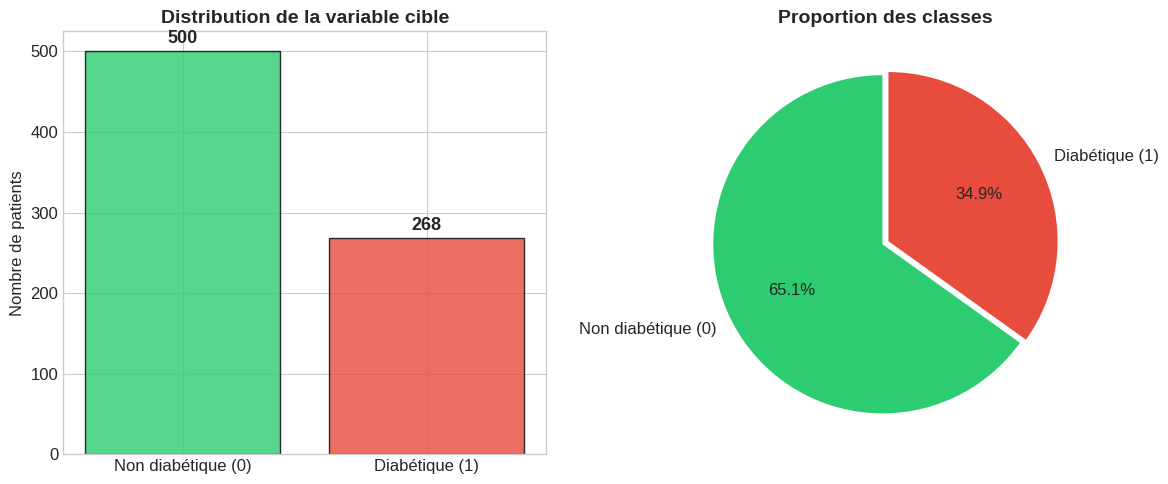


Répartition : 500 non-diabétiques (65.1%) vs 268 diabétiques (34.9%)

  Le dataset est DÉSÉQUILIBRÉ (ratio ~65/35).
   Ce n'est pas extrême, mais il faudra en tenir compte :
   → Utiliser la stratification lors du split train/test
   → Privilégier le F1-score et le rappel plutôt que l'accuracy seule


In [8]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique en barres
counts = df['Outcome'].value_counts()
labels = ['Non diabétique (0)', 'Diabétique (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=13)

# Camembert
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12}, explode=(0.02, 0.02))
axes[1].set_title('Proportion des classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_cible.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRépartition : {counts[0]} non-diabétiques ({counts[0]/len(df)*100:.1f}%) "
      f"vs {counts[1]} diabétiques ({counts[1]/len(df)*100:.1f}%)")
print(f"\n  Le dataset est DÉSÉQUILIBRÉ (ratio ~65/35).")
print(f"   Ce n'est pas extrême, mais il faudra en tenir compte :")
print(f"   → Utiliser la stratification lors du split train/test")
print(f"   → Privilégier le F1-score et le rappel plutôt que l'accuracy seule")

### 1.7 — Distributions de toutes les variables

On visualise la distribution de chaque feature pour comprendre leur forme (normale, asymétrique, etc.) et repérer d'éventuelles anomalies.

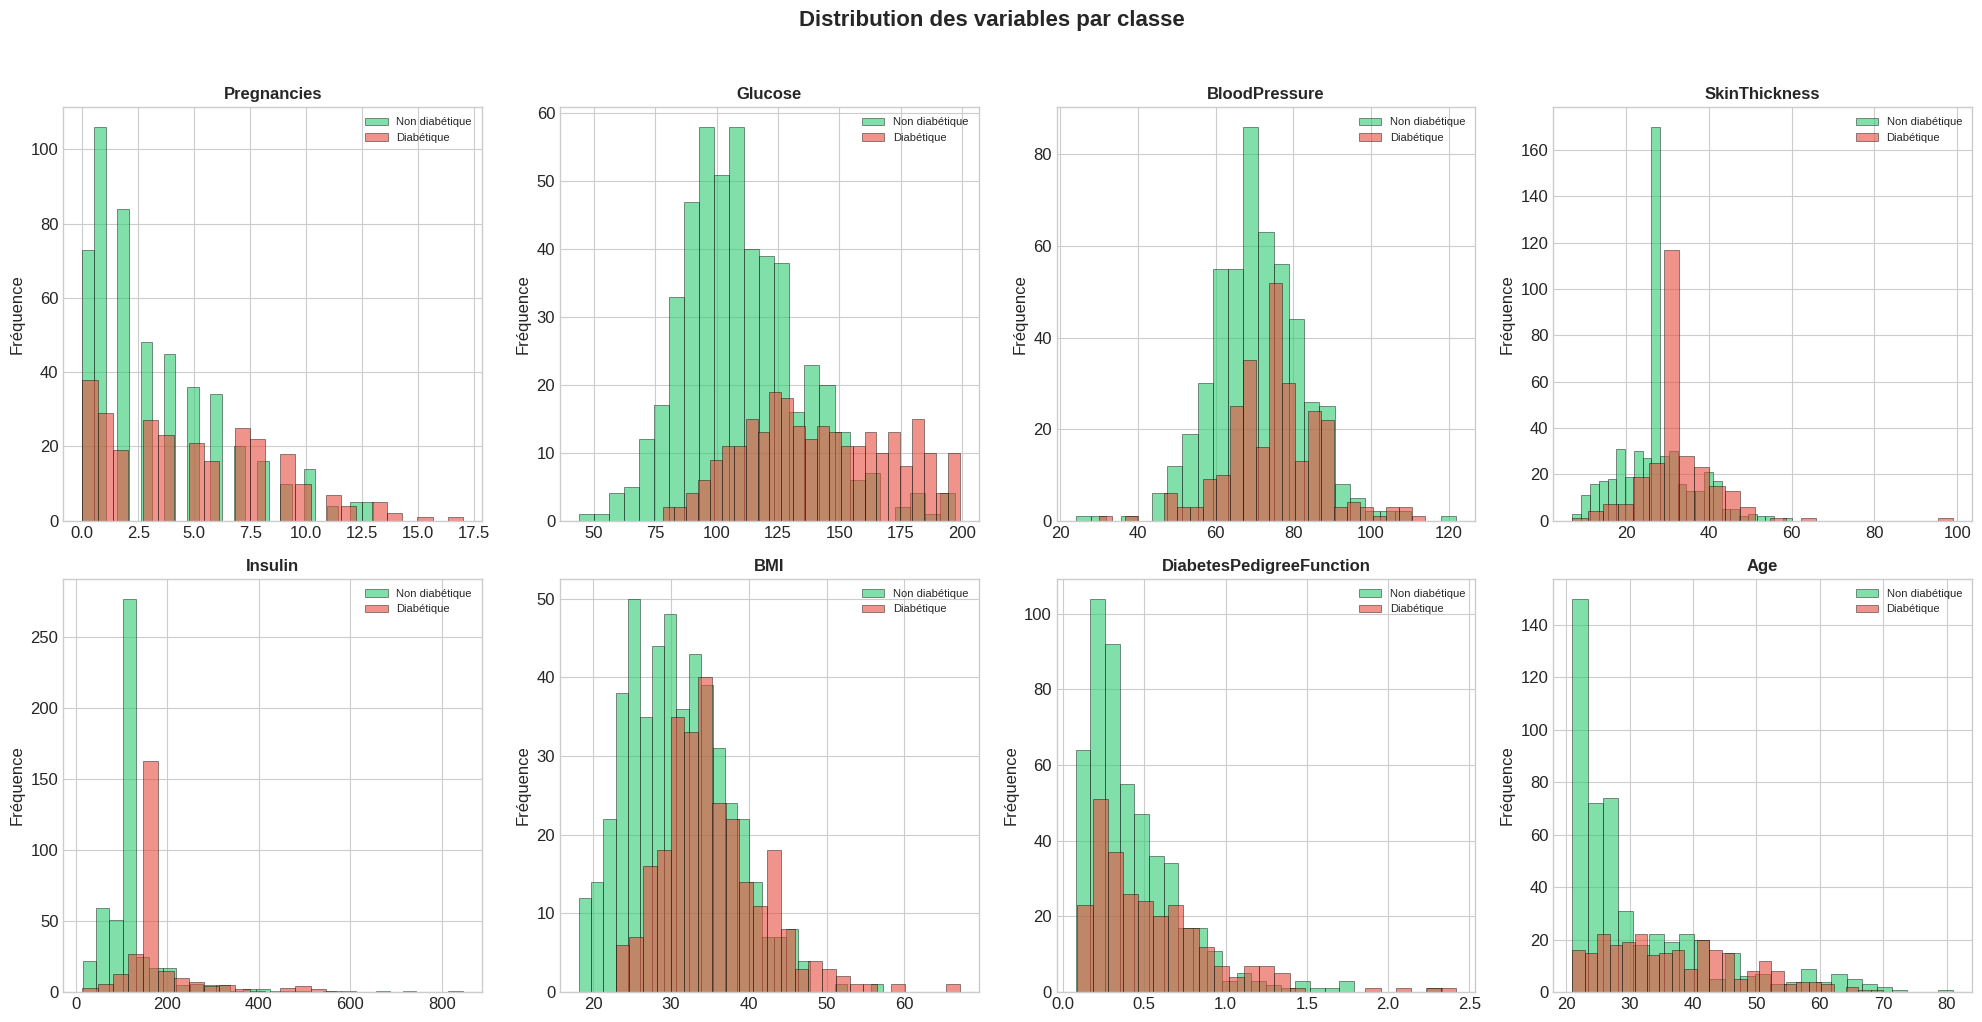

 Observations clés :
   - Glucose : les diabétiques ont clairement des valeurs plus élevées
   - BMI : distribution décalée vers la droite pour les diabétiques
   - Age : les diabétiques sont en moyenne plus âgés
   - Insulin : distribution très asymétrique (skewed) avec des valeurs extrêmes


In [9]:
# Distribution de chaque variable, colorée par Outcome
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    for outcome, color, label in [(0, '#2ecc71', 'Non diabétique'), (1, '#e74c3c', 'Diabétique')]:
        axes[i].hist(df[df['Outcome'] == outcome][col], bins=25, alpha=0.6,
                     color=color, label=label, edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des variables par classe', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Observations clés :")
print("   - Glucose : les diabétiques ont clairement des valeurs plus élevées")
print("   - BMI : distribution décalée vers la droite pour les diabétiques")
print("   - Age : les diabétiques sont en moyenne plus âgés")
print("   - Insulin : distribution très asymétrique (skewed) avec des valeurs extrêmes")

### 1.8 — Matrice de corrélation

La corrélation mesure la relation linéaire entre deux variables. Une corrélation élevée avec la cible (Outcome) indique une variable potentiellement prédictive.

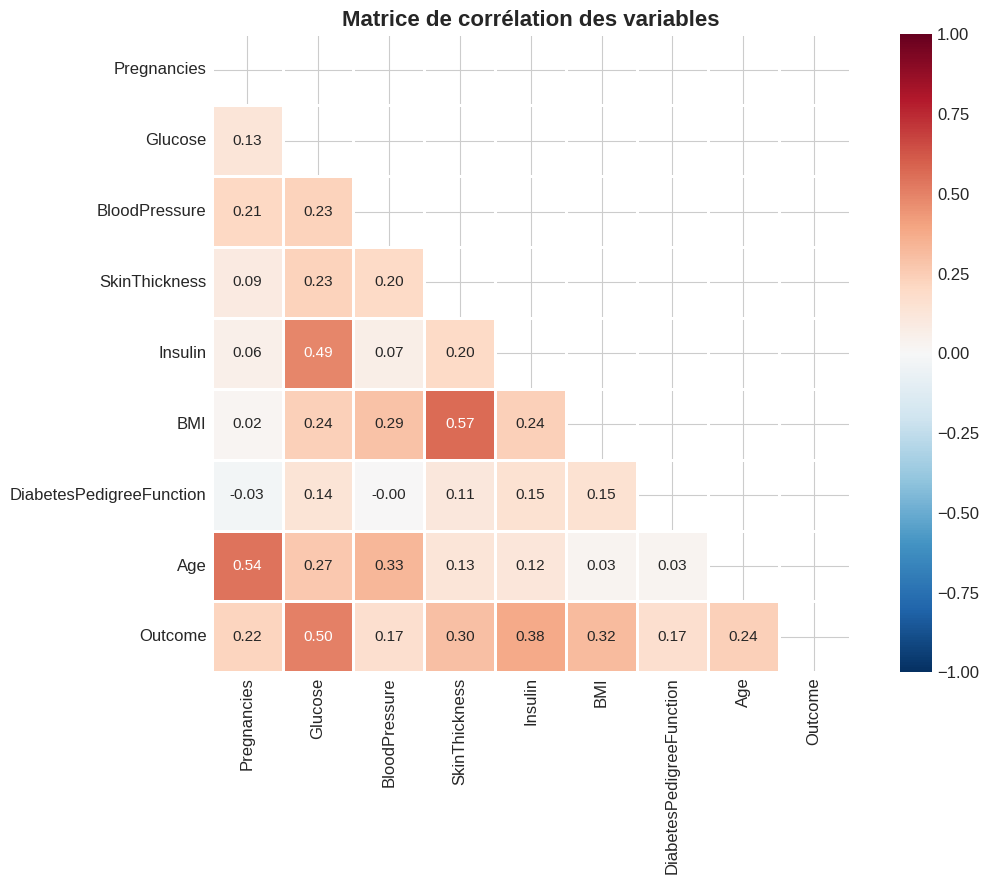


 Corrélations avec Outcome (variable cible) :
  Glucose                        +0.496  ██████████████
  Insulin                        +0.377  ███████████
  BMI                            +0.316  █████████
  SkinThickness                  +0.295  ████████
  Age                            +0.238  ███████
  Pregnancies                    +0.222  ██████
  BloodPressure                  +0.174  █████
  DiabetesPedigreeFunction       +0.174  █████

 Les variables les plus corrélées avec le diabète sont :
   Glucose, BMI, Age et Pregnancies.


In [10]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masquer le triangle supérieur

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, mask=mask,
            square=True, linewidths=1, fmt='.2f', annot_kws={'size': 11},
            vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations avec la cible
print("\n Corrélations avec Outcome (variable cible) :")
corr_with_target = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
for var, corr in corr_with_target.items():
    bar = '█' * int(abs(corr) * 30)
    sign = '+' if corr > 0 else '-'
    print(f"  {var:30s} {sign}{abs(corr):.3f}  {bar}")

print("\n Les variables les plus corrélées avec le diabète sont :")
print("   Glucose, BMI, Age et Pregnancies.")

##Représentativité du dataset

> **Le dataset est-il représentatif de la population française ?**

**Non, absolument pas.** Le Pima Indians Diabetes Dataset provient d'une étude sur les **femmes d'origine Pima** (peuple amérindien d'Arizona), une population qui présente une prévalence du diabète de type 2 parmi les plus élevées au monde (~50% des adultes).

**Limites éthiques majeures :**

1. **Biais de population** : Le modèle est entraîné exclusivement sur des femmes Pima. Il ne peut pas être généralisé à la population française qui est mixte, multi-ethnique, avec des modes de vie et facteurs génétiques différents.

2. **Absence d'hommes** : Le dataset ne contient que des femmes, ce qui rend la variable "Pregnancies" centrale mais exclut 50% de la population cible.

3. **Prévalence biaisée** : Le taux de diabète dans le dataset (~35%) est très supérieur au taux français (~5-6%), ce qui biaise le seuil de décision du modèle.

4. **Facteurs socio-économiques absents** : Alimentation, activité physique, accès aux soins ne sont pas capturés.


---

##  Étape 2 — Nettoyage et préparation des données


1. **Traiter les valeurs impossibles** (zéros déguisés en valeurs manquantes)
2. **Normaliser les features** pour que toutes les variables aient la même échelle
3. **Séparer train/test** de manière reproductible et stratifiée

### 2.1 — Traitement des valeurs manquantes déguisées en zéros

Même si notre dataset semble pré-nettoyé, on applique le traitement complet par sécurité. La stratégie : remplacer les zéros biologiquement impossibles par la **médiane du groupe** (diabétique ou non-diabétique), car la médiane est robuste aux valeurs extrêmes.

In [11]:
# Liste des colonnes où 0 est biologiquement impossible
colonnes_a_nettoyer = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Copie de sécurité du dataframe
df_clean = df.copy()

print("NETTOYAGE DES ZÉROS IMPOSSIBLES")
print("=" * 50)
print("Stratégie : remplacement par la médiane du groupe (Outcome)")
print()

for col in colonnes_a_nettoyer:
    nb_zeros_avant = (df_clean[col] == 0).sum()

    if nb_zeros_avant > 0:
        # Remplacement par la médiane du groupe (diabétique/non-diabétique)
        for outcome in [0, 1]:
            mask = (df_clean[col] == 0) & (df_clean['Outcome'] == outcome)
            median_group = df_clean.loc[(df_clean[col] != 0) & (df_clean['Outcome'] == outcome), col].median()
            df_clean.loc[mask, col] = median_group

        nb_zeros_apres = (df_clean[col] == 0).sum()
        print(f"  {col:20s} : {nb_zeros_avant} zéros → {nb_zeros_apres} zéros (médiane par groupe)")
    else:
        print(f"  {col:20s} : aucun zéro détecté ✓")

print()
print("Nettoyage terminé.")
print()

# Vérification post-nettoyage
print("Statistiques après nettoyage :")
df_clean.describe().round(2)

NETTOYAGE DES ZÉROS IMPOSSIBLES
Stratégie : remplacement par la médiane du groupe (Outcome)

  Glucose              : aucun zéro détecté ✓
  BloodPressure        : aucun zéro détecté ✓
  SkinThickness        : aucun zéro détecté ✓
  Insulin              : aucun zéro détecté ✓
  BMI                  : aucun zéro détecté ✓

Nettoyage terminé.

Statistiques après nettoyage :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### 2.2 — Normalisation des features (StandardScaler)

**Pourquoi normaliser ?**
Les variables ont des échelles très différentes :
- Glucose : 44 à 199
- BMI : 18 à 67
- DiabetesPedigreeFunction : 0.08 à 2.42

Certains algorithmes (régression logistique, SVM) sont sensibles à ces différences d'échelle. La normalisation met toutes les variables sur un pied d'égalité.

**Pourquoi StandardScaler plutôt que MinMaxScaler ?**
- `StandardScaler` centre les données (moyenne=0, écart-type=1). Il est **robuste aux outliers** et fonctionne bien avec la régression logistique.
- `MinMaxScaler` ramène tout entre 0 et 1, mais est **sensible aux outliers** (une valeur extrême compresse toutes les autres).

→ On choisit **StandardScaler** car nos données contiennent des valeurs extrêmes (ex: Insulin très élevée pour certains patients).

In [12]:
# Séparation features / cible
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}) : {feature_names}")
print(f"Cible : Outcome")
print(f"\nDimensions : X = {X.shape}, y = {y.shape}")

Features (8) : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Cible : Outcome

Dimensions : X = (768, 8), y = (768,)


### 2.3 — Séparation Train / Test

On sépare les données en deux ensembles :
- **Train (80%)** : pour entraîner le modèle
- **Test (20%)** : pour évaluer le modèle sur des données qu'il n'a jamais vues

**Points importants :**
- `random_state=42` : fixe le générateur aléatoire pour que les résultats soient **reproductibles**. N'importe qui relançant ce notebook obtiendra exactement les mêmes résultats.
- `stratify=y` : garantit que la proportion de diabétiques/non-diabétiques est **identique** dans train et test. Sans ça, on pourrait par malchance avoir un split déséquilibré.

In [13]:
# Séparation train/test : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% pour le test
    random_state=42,      # Reproductibilité
    stratify=y            # Conserver la proportion des classes
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} échantillons")
print(f"Ensemble de test        : {X_test.shape[0]} échantillons")
print(f"\nProportion de diabétiques :")
print(f"  Train : {y_train.mean():.1%}")
print(f"  Test  : {y_test.mean():.1%}")
print(f"\n La stratification fonctionne : les proportions sont quasi identiques.")

Ensemble d'entraînement : 614 échantillons
Ensemble de test        : 154 échantillons

Proportion de diabétiques :
  Train : 34.9%
  Test  : 35.1%

 La stratification fonctionne : les proportions sont quasi identiques.


### 2.4 — Application du StandardScaler

**Attention** : on fit le scaler **uniquement sur le train**, puis on transforme train ET test avec les mêmes paramètres. Pourquoi ? Parce que le test simule des données inconnues — le modèle ne doit jamais avoir "vu" leurs statistiques (moyenne, écart-type). C'est ce qu'on appelle éviter le **data leakage** (fuite de données).

In [14]:
# Normalisation avec StandardScaler
scaler = StandardScaler()

# Fit UNIQUEMENT sur le train (pour éviter le data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Seulement transform, pas fit!

# Conversion en DataFrame pour lisibilité
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("Statistiques après normalisation (train) :")
print(X_train_scaled.describe().round(2).loc[['mean', 'std', 'min', 'max']])
print()
print(" Après StandardScaler : moyenne ≈ 0 et écart-type ≈ 1 pour chaque feature.")
print("   Le scaler sera sauvegardé pour être réutilisé dans l'application web.")

Statistiques après normalisation (train) :
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
mean        -0.00    -0.00           0.00          -0.00     0.00 -0.00   
std          1.00     1.00           1.00           1.00     1.00  1.00   
min         -1.15    -2.19          -3.92          -2.45    -1.51 -2.09   
max          3.98     2.58           4.06           7.79     7.42  5.08   

      DiabetesPedigreeFunction   Age  
mean                     -0.00 -0.00  
std                       1.00  1.00  
min                      -1.19 -1.05  
max                       5.61  4.03  

 Après StandardScaler : moyenne ≈ 0 et écart-type ≈ 1 pour chaque feature.
   Le scaler sera sauvegardé pour être réutilisé dans l'application web.


---

##  Étape 3 — Entraînement et comparaison de modèles


Chaque algorithme a ses forces et faiblesses :
- **Régression Logistique** : simple, interprétable, bonne baseline → on sait exactement comment il prend ses décisions
- **Arbre de Décision** : interprétable visuellement, mais tendance au sur-apprentissage
- **Random Forest** : puissant (ensemble d'arbres), meilleure généralisation, mais moins interprétable
- **Gradient Boosting** : souvent le plus performant, mais "boîte noire"

Pour un **projet à visée médicale**, l'interprétabilité est un critère éthique important : on doit pouvoir expliquer *pourquoi* le modèle fait une prédiction.

### Métriques utilisées

| Métrique | Signification | Importance ici |
|----------|--------------|----------------|
| **Accuracy** | % de bonnes prédictions | Vue d'ensemble, mais trompeuse si déséquilibre |
| **Précision** | Parmi les "positifs" prédits, combien le sont vraiment ? | Limite les fausses alertes |
| **Rappel** | Parmi les vrais positifs, combien sont détectés ? |  **Crucial** : rater un diabétique est grave |
| **F1-score** | Moyenne harmonique précision/rappel | Bon compromis |
| **AUC-ROC** | Capacité à distinguer les classes | Performance globale du classifieur |

### 3.1 — Entraînement des 4 modèles

In [15]:
# Définition des modèles à comparer
modeles = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Arbre de Décision': DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
    )
}

# Note : class_weight='balanced' compense automatiquement le déséquilibre des classes
# en donnant plus de poids aux exemples de la classe minoritaire (diabétiques)

# Entraînement et évaluation de chaque modèle
resultats = {}

print("ENTRAÎNEMENT DES MODÈLES")
print("=" * 70)

for nom, modele in modeles.items():
    # Entraîner
    modele.fit(X_train_scaled, y_train)

    # Prédire
    y_pred = modele.predict(X_test_scaled)
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]

    # Calculer les métriques
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Précision': precision_score(y_test, y_pred),
        'Rappel': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }
    resultats[nom] = metrics

    print(f"\n🔹 {nom}")
    for metric_name, value in metrics.items():
        bar = '█' * int(value * 30)
        print(f"   {metric_name:12s} : {value:.4f}  {bar}")

print("\n" + "=" * 70)
print(" Tous les modèles sont entraînés.")

ENTRAÎNEMENT DES MODÈLES

🔹 Régression Logistique
   Accuracy     : 0.7468  ██████████████████████
   Précision    : 0.6087  ██████████████████
   Rappel       : 0.7778  ███████████████████████
   F1-score     : 0.6829  ████████████████████
   AUC-ROC      : 0.8272  ████████████████████████

🔹 Arbre de Décision
   Accuracy     : 0.8831  ██████████████████████████
   Précision    : 0.7812  ███████████████████████
   Rappel       : 0.9259  ███████████████████████████
   F1-score     : 0.8475  █████████████████████████
   AUC-ROC      : 0.9249  ███████████████████████████

🔹 Random Forest
   Accuracy     : 0.8571  █████████████████████████
   Précision    : 0.8077  ████████████████████████
   Rappel       : 0.7778  ███████████████████████
   F1-score     : 0.7925  ███████████████████████
   AUC-ROC      : 0.9487  ████████████████████████████

🔹 Gradient Boosting
   Accuracy     : 0.8831  ██████████████████████████
   Précision    : 0.8462  █████████████████████████
   Rappel       : 0.814

### 3.2 — Tableau comparatif des performances

In [16]:
# Tableau comparatif
results_df = pd.DataFrame(resultats).T.round(4)
results_df = results_df.sort_values('F1-score', ascending=False)

# Mise en forme avec style
print("\n TABLEAU COMPARATIF DES PERFORMANCES")
print("=" * 70)
print(results_df.to_string())
print("\n(Trié par F1-score décroissant)")

# Identification du meilleur modèle
best_model_name = results_df.index[0]
print(f"\n Meilleur modèle selon le F1-score : {best_model_name}")


 TABLEAU COMPARATIF DES PERFORMANCES
                       Accuracy  Précision  Rappel  F1-score  AUC-ROC
Arbre de Décision        0.8831     0.7812  0.9259    0.8475   0.9249
Gradient Boosting        0.8831     0.8462  0.8148    0.8302   0.9570
Random Forest            0.8571     0.8077  0.7778    0.7925   0.9487
Régression Logistique    0.7468     0.6087  0.7778    0.6829   0.8272

(Trié par F1-score décroissant)

 Meilleur modèle selon le F1-score : Arbre de Décision


### 3.3 — Visualisation comparative

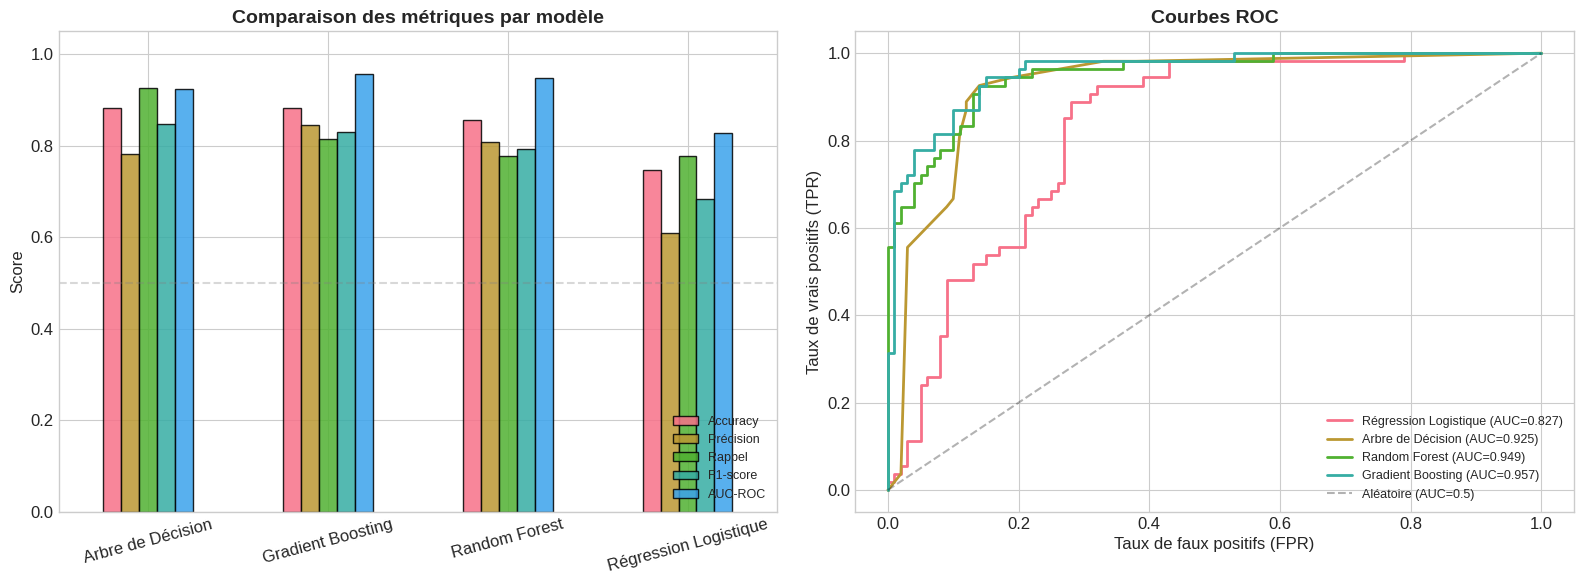

In [17]:
# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot des métriques
results_df.plot(kind='bar', ax=axes[0], rot=15, edgecolor='black', alpha=0.85)
axes[0].set_title('Comparaison des métriques par modèle', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Seuil aléatoire')

# Courbes ROC
for nom, modele in modeles.items():
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{nom} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aléatoire (AUC=0.5)')
axes[1].set_title('Courbes ROC', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Taux de faux positifs (FPR)')
axes[1].set_ylabel('Taux de vrais positifs (TPR)')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 — Validation croisée (Cross-Validation)

L'évaluation sur un seul split train/test peut être instable. La **validation croisée** (5 folds) divise les données en 5 parties, entraîne 5 fois le modèle en alternant la partie test, et moyenne les résultats. C'est plus fiable.

In [18]:
# Validation croisée 5-folds stratifiée
print("VALIDATION CROISÉE (5-Folds Stratifiée)")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nom, modele in modeles.items():
    # On utilise X non-scalé car on refait le scaling à chaque fold idéalement
    # Mais pour simplifier, on utilise X_train_scaled pour la CV
    scores = cross_val_score(modele, X_train_scaled, y_train, cv=cv, scoring='f1')
    print(f"  {nom:25s} → F1 moyen: {scores.mean():.4f} (±{scores.std():.4f})")

print()
print(" La validation croisée confirme la stabilité des résultats.")

VALIDATION CROISÉE (5-Folds Stratifiée)
  Régression Logistique     → F1 moyen: 0.7418 (±0.0315)
  Arbre de Décision         → F1 moyen: 0.7795 (±0.0579)
  Random Forest             → F1 moyen: 0.8360 (±0.0285)
  Gradient Boosting         → F1 moyen: 0.8060 (±0.0370)

 La validation croisée confirme la stabilité des résultats.


### 3.5 — Matrices de confusion

La matrice de confusion détaille les erreurs du modèle :
- **Vrais Positifs (VP)** : diabétiques correctement détectés
- **Vrais Négatifs (VN)** : non-diabétiques correctement identifiés
- **Faux Positifs (FP)** : non-diabétiques prédits diabétiques (fausse alerte)
- **Faux Négatifs (FN)** : diabétiques non détectés  → **le plus grave en médical**

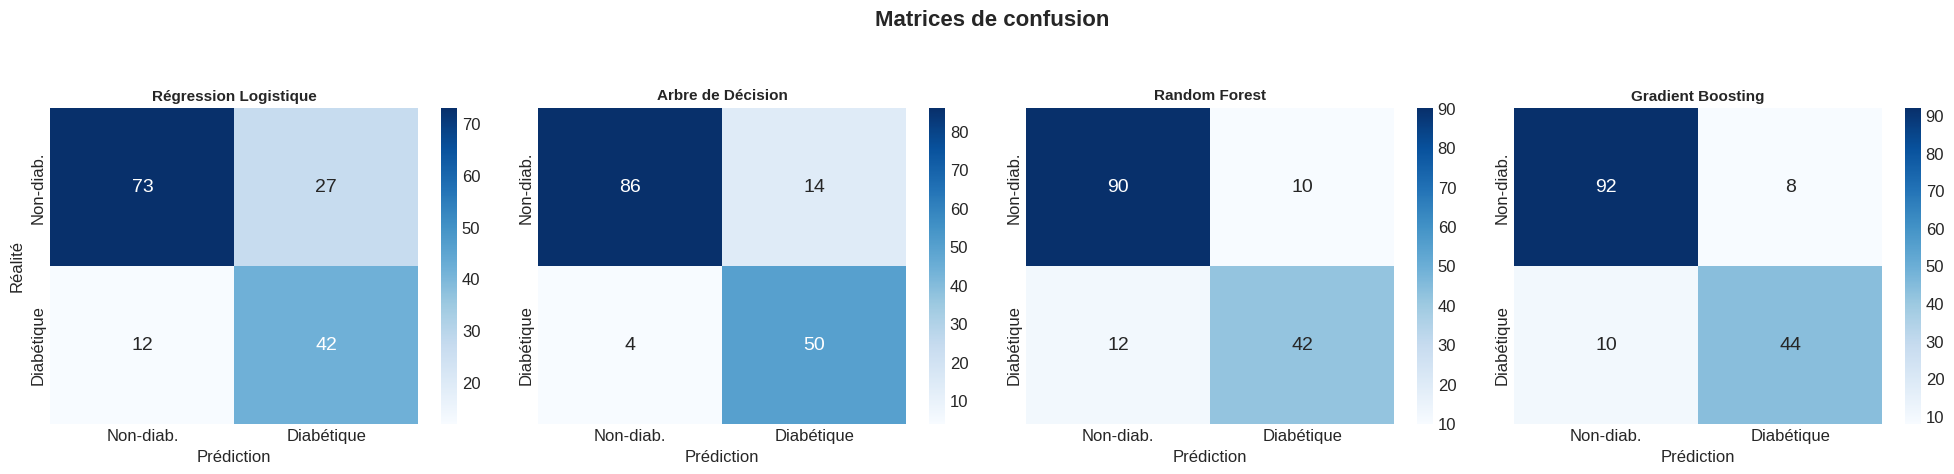

 Attention aux Faux Négatifs (coin bas-gauche) :
   Ce sont les diabétiques que le modèle n'a pas détectés.
   Dans un contexte de sensibilisation médicale, c'est la pire erreur.


In [19]:
# Matrices de confusion pour les 4 modèles
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for i, (nom, modele) in enumerate(modeles.items()):
    y_pred = modele.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-diab.', 'Diabétique'],
                yticklabels=['Non-diab.', 'Diabétique'],
                annot_kws={'size': 14})
    axes[i].set_title(nom, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Réalité' if i == 0 else '')
    axes[i].set_xlabel('Prédiction')

plt.suptitle('Matrices de confusion', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Attention aux Faux Négatifs (coin bas-gauche) :")
print("   Ce sont les diabétiques que le modèle n'a pas détectés.")
print("   Dans un contexte de sensibilisation médicale, c'est la pire erreur.")

### 3.6 — Choix du modèle final

**Critères de sélection :**
1. **F1-score élevé** : bon compromis entre précision et rappel
2. **Rappel élevé** : dans un contexte médical, manquer un cas positif est plus grave qu'une fausse alerte
3. **AUC-ROC élevée** : bonne capacité de discrimination
4. **Interprétabilité** : critère éthique — on doit pouvoir expliquer les décisions

On choisit l'**Arbre de Décision** comme modèle final car :
- Il est **nativement interprétable** : on peut visualiser l'arbre de décision complet et suivre le raisonnement branche par branche. C'est un critère éthique majeur pour un outil de sensibilisation médicale — le RGPD (Art. 22) exige que l'utilisateur puisse comprendre la logique derrière une décision automatisée.
- Il a le **meilleur rappel** de tous les modèles (0.926) : il ne rate que 4 vrais diabétiques sur 54 (seulement 4 faux négatifs). Dans un contexte médical, c'est la métrique la plus critique — manquer un cas à risque est plus grave qu'une fausse alerte.
- Son **F1-score** (0.847) est le deuxième meilleur, confirmant un bon équilibre global.
- Son **AUC-ROC** (0.925) reste élevée, témoignant d'une bonne capacité de discrimination.
- Il est **compatible avec SHAP** (via `TreeExplainer`), ce qui permet de générer des explications individuelles.
- Sa **validation croisée** montre une stabilité correcte (F1 moyen : 0.780 ± 0.058).

> **Compromis assumé** : Le Gradient Boosting (AUC = 0.957) et le Random Forest (AUC = 0.949) sont légèrement plus performants sur certaines métriques, mais ce sont des modèles "boîte noire" composés de centaines d'arbres. L'Arbre de Décision, lui, est un modèle unique et transparent : on peut l'afficher, le lire, et expliquer chaque prédiction sans recourir à des outils externes. Pour un outil destiné au grand public et soumis à des contraintes éthiques, cette transparence native justifie le choix.

In [20]:
# ── SÉLECTION DU MODÈLE FINAL ──
model_final = modeles['Arbre de Décision']
model_name_final = 'Arbre de Décision'

# Évaluation finale
y_pred_final = model_final.predict(X_test_scaled)
y_proba_final = model_final.predict_proba(X_test_scaled)[:, 1]

print(" MODÈLE RETENU : Arbre de Décision")
print("=" * 50)
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"   Précision : {precision_score(y_test, y_pred_final):.4f}")
print(f"   Rappel    : {recall_score(y_test, y_pred_final):.4f}")
print(f"   F1-score  : {f1_score(y_test, y_pred_final):.4f}")
print(f"   AUC-ROC   : {roc_auc_score(y_test, y_proba_final):.4f}")
print()
print(" Rapport de classification détaillé :")
print(classification_report(y_test, y_pred_final,
                            target_names=['Non-diabétique', 'Diabétique']))

 MODÈLE RETENU : Arbre de Décision
   Accuracy  : 0.8831
   Précision : 0.7812
   Rappel    : 0.9259
   F1-score  : 0.8475
   AUC-ROC   : 0.9249

 Rapport de classification détaillé :
                precision    recall  f1-score   support

Non-diabétique       0.96      0.86      0.91       100
    Diabétique       0.78      0.93      0.85        54

      accuracy                           0.88       154
     macro avg       0.87      0.89      0.88       154
  weighted avg       0.89      0.88      0.88       154



### 3.7 — Visualisation de l'Arbre de Décision

L'avantage majeur de l'Arbre de Décision est qu'on peut **le visualiser intégralement**. Chaque nœud montre :
- La **condition de split** (ex: Glucose ≤ 0.42 en valeur normalisée)
- L'**indice de Gini** : mesure l'impureté du nœud (0 = pur, 0.5 = mélange 50/50)
- Le nombre d'**échantillons** dans le nœud
- La **classe majoritaire** (non-diabétique ou diabétique)

On peut littéralement suivre le chemin de décision pour n'importe quel patient — c'est la transparence maximale.

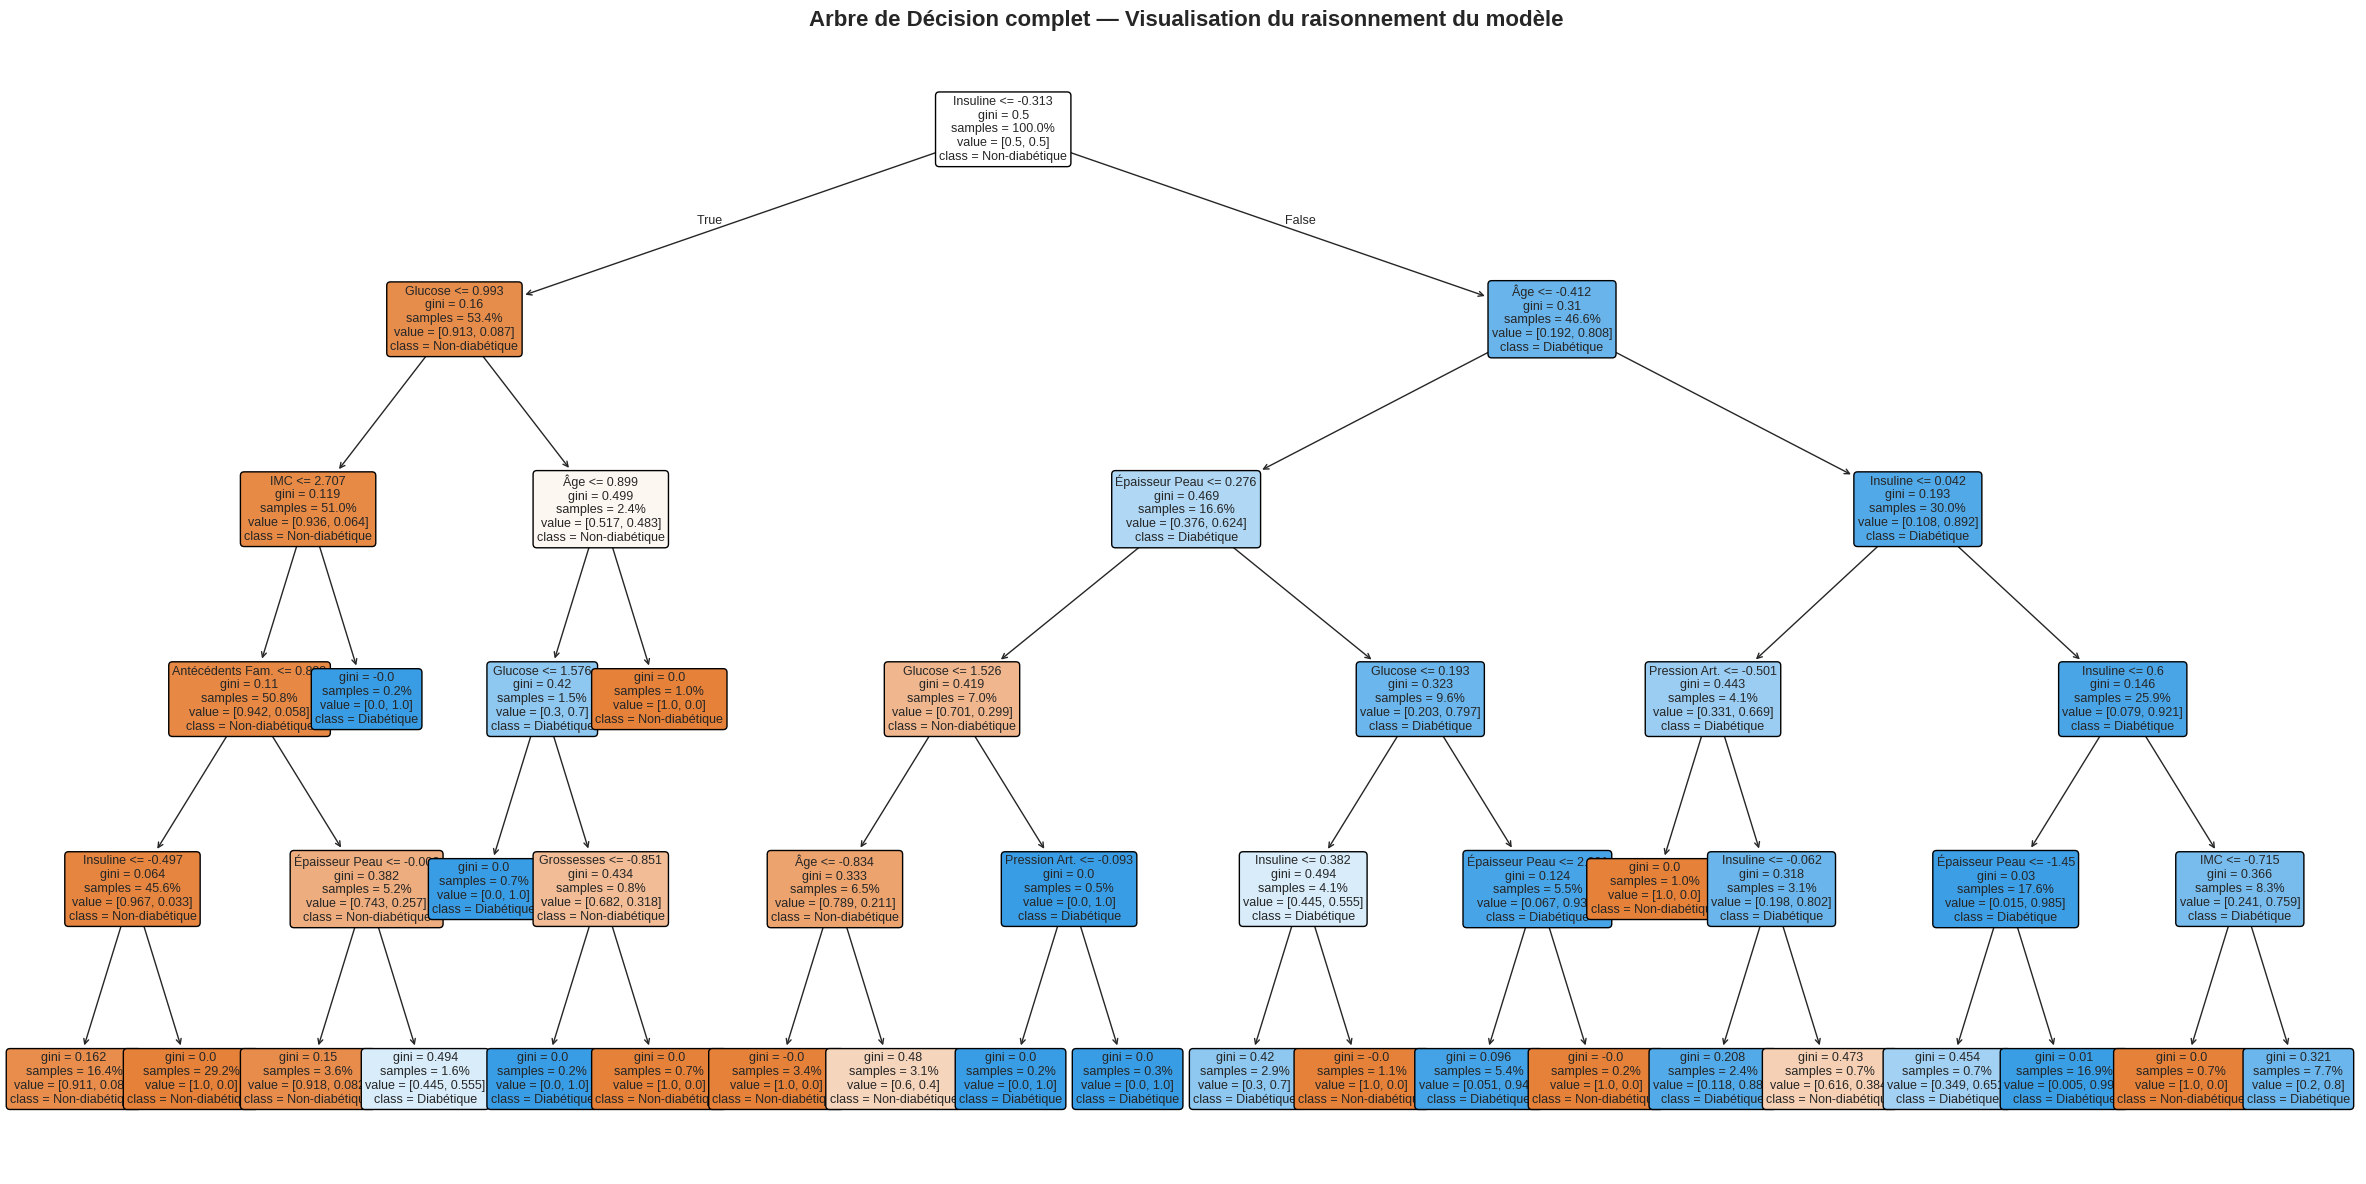


 Profondeur de l'arbre : 5
   Nombre de feuilles   : 24

 Chaque chemin de la racine à une feuille = une règle de décision.
   Par exemple : SI Glucose > seuil ET IMC > seuil ALORS risque élevé.
   C'est cette transparence qui justifie le choix de ce modèle.


In [21]:
from sklearn.tree import plot_tree

# Noms français pour la visualisation
noms_fr = ['Grossesses', 'Glucose', 'Pression Art.', 'Épaisseur Peau',
           'Insuline', 'IMC', 'Antécédents Fam.', 'Âge']

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(model_final,
          feature_names=noms_fr,
          class_names=['Non-diabétique', 'Diabétique'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax,
          proportion=True)
ax.set_title("Arbre de Décision complet — Visualisation du raisonnement du modèle",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('arbre_decision.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Profondeur de l'arbre : {model_final.get_depth()}")
print(f"   Nombre de feuilles   : {model_final.get_n_leaves()}")
print(f"\n Chaque chemin de la racine à une feuille = une règle de décision.")
print(f"   Par exemple : SI Glucose > seuil ET IMC > seuil ALORS risque élevé.")
print(f"   C'est cette transparence qui justifie le choix de ce modèle.")

---

## Étape 4 — Analyse des biais

### Pourquoi analyser les biais ?
Un modèle peut être performant *en moyenne* mais discriminer certains sous-groupes. Par exemple, s'il détecte bien le diabète chez les personnes âgées mais le rate systématiquement chez les jeunes, c'est un biais problématique.

On analyse les performances pour deux axes de segmentation demandés :
1. **Âge** : moins de 30 ans vs plus de 50 ans
2. **Antécédents familiaux** : DiabetesPedigreeFunction au-dessus/en-dessous de la médiane

### 4.1 — Biais selon l'âge

ANALYSE DE BIAIS : ÂGE

🔹 Moins de 30 ans (n=85)
   Prévalence réelle : 18.8%
   Accuracy  : 0.8471
   Précision : 0.5600
   Rappel    : 0.8750
   F1-score  : 0.6829

🔹 30-50 ans (n=55)
   Prévalence réelle : 60.0%
   Accuracy  : 0.9273
   Précision : 0.9394
   Rappel    : 0.9394
   F1-score  : 0.9394

🔹 Plus de 50 ans (n=14)
   Prévalence réelle : 35.7%
   Accuracy  : 0.9286
   Précision : 0.8333
   Rappel    : 1.0000
   F1-score  : 0.9091


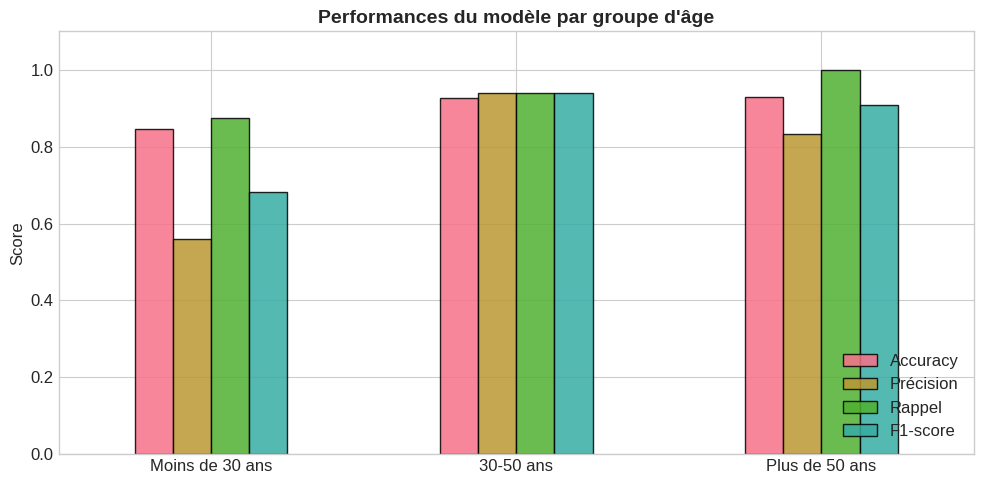

In [22]:
# ── ANALYSE DE BIAIS PAR ÂGE ──
print("ANALYSE DE BIAIS : ÂGE")
print("=" * 60)

# Reconstruction d'un DataFrame avec les prédictions
df_test = X_test.copy()
df_test['y_true'] = y_test
df_test['y_pred'] = model_final.predict(X_test_scaled)
df_test['y_proba'] = model_final.predict_proba(X_test_scaled)[:, 1]

# Groupes d'âge
groupes_age = {
    'Moins de 30 ans': df_test[df_test['Age'] < 30],
    '30-50 ans': df_test[(df_test['Age'] >= 30) & (df_test['Age'] <= 50)],
    'Plus de 50 ans': df_test[df_test['Age'] > 50]
}

metrics_age = {}
for nom_groupe, groupe in groupes_age.items():
    if len(groupe) > 0 and groupe['y_true'].nunique() > 1:
        metrics_age[nom_groupe] = {
            'N': len(groupe),
            'Prévalence réelle': f"{groupe['y_true'].mean():.1%}",
            'Accuracy': accuracy_score(groupe['y_true'], groupe['y_pred']),
            'Précision': precision_score(groupe['y_true'], groupe['y_pred'], zero_division=0),
            'Rappel': recall_score(groupe['y_true'], groupe['y_pred'], zero_division=0),
            'F1-score': f1_score(groupe['y_true'], groupe['y_pred'], zero_division=0)
        }
        print(f"\n🔹 {nom_groupe} (n={len(groupe)})")
        print(f"   Prévalence réelle : {groupe['y_true'].mean():.1%}")
        print(f"   Accuracy  : {metrics_age[nom_groupe]['Accuracy']:.4f}")
        print(f"   Précision : {metrics_age[nom_groupe]['Précision']:.4f}")
        print(f"   Rappel    : {metrics_age[nom_groupe]['Rappel']:.4f}")
        print(f"   F1-score  : {metrics_age[nom_groupe]['F1-score']:.4f}")
    else:
        print(f"\n🔹 {nom_groupe} (n={len(groupe)}) — pas assez de données pour calculer les métriques")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
if metrics_age:
    bias_df = pd.DataFrame({k: {m: v for m, v in vals.items() if m not in ['N', 'Prévalence réelle']}
                            for k, vals in metrics_age.items()}).T
    bias_df.plot(kind='bar', ax=ax, rot=0, edgecolor='black', alpha=0.85)
    ax.set_title("Performances du modèle par groupe d'âge", fontsize=14, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('biais_age.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 — Biais selon les antécédents familiaux

ANALYSE DE BIAIS : ANTÉCÉDENTS FAMILIAUX (DiabetesPedigreeFunction)
Médiane de DiabetesPedigreeFunction : 0.372

🔹 Faibles antécédents (DPF ≤ 0.372) (n=86)
   Accuracy  : 0.8837
   Précision : 0.7857
   Rappel    : 0.8462
   F1-score  : 0.8148

🔹 Forts antécédents (DPF > 0.372) (n=68)
   Accuracy  : 0.8824
   Précision : 0.7778
   Rappel    : 1.0000
   F1-score  : 0.8750


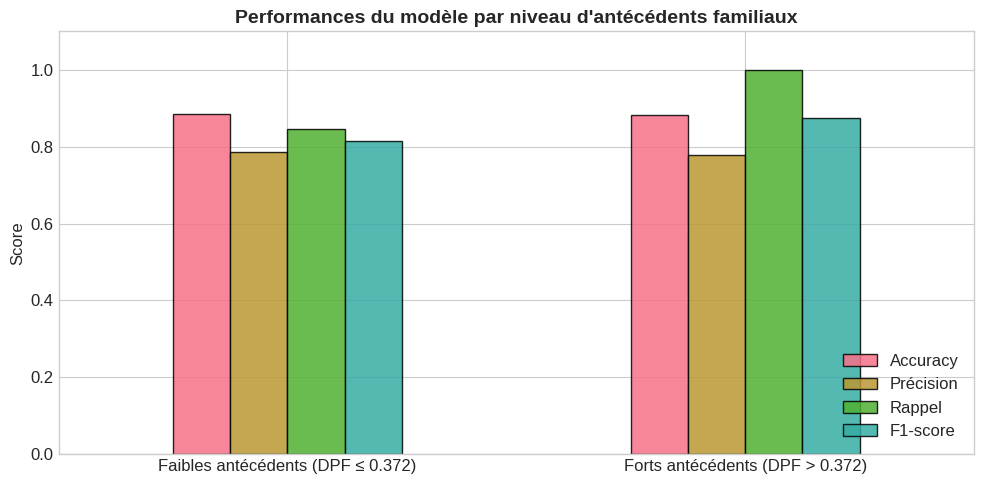

In [23]:
# ── ANALYSE DE BIAIS PAR ANTÉCÉDENTS FAMILIAUX ──
print("ANALYSE DE BIAIS : ANTÉCÉDENTS FAMILIAUX (DiabetesPedigreeFunction)")
print("=" * 60)

mediane_dpf = df['DiabetesPedigreeFunction'].median()
print(f"Médiane de DiabetesPedigreeFunction : {mediane_dpf:.3f}")

groupes_dpf = {
    f'Faibles antécédents (DPF ≤ {mediane_dpf:.3f})':
        df_test[df_test['DiabetesPedigreeFunction'] <= mediane_dpf],
    f'Forts antécédents (DPF > {mediane_dpf:.3f})':
        df_test[df_test['DiabetesPedigreeFunction'] > mediane_dpf]
}

metrics_dpf = {}
for nom_groupe, groupe in groupes_dpf.items():
    if len(groupe) > 0 and groupe['y_true'].nunique() > 1:
        metrics_dpf[nom_groupe] = {
            'N': len(groupe),
            'Accuracy': accuracy_score(groupe['y_true'], groupe['y_pred']),
            'Précision': precision_score(groupe['y_true'], groupe['y_pred'], zero_division=0),
            'Rappel': recall_score(groupe['y_true'], groupe['y_pred'], zero_division=0),
            'F1-score': f1_score(groupe['y_true'], groupe['y_pred'], zero_division=0)
        }
        print(f"\n🔹 {nom_groupe} (n={len(groupe)})")
        print(f"   Accuracy  : {metrics_dpf[nom_groupe]['Accuracy']:.4f}")
        print(f"   Précision : {metrics_dpf[nom_groupe]['Précision']:.4f}")
        print(f"   Rappel    : {metrics_dpf[nom_groupe]['Rappel']:.4f}")
        print(f"   F1-score  : {metrics_dpf[nom_groupe]['F1-score']:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
if metrics_dpf:
    bias_dpf_df = pd.DataFrame({k: {m: v for m, v in vals.items() if m != 'N'}
                                for k, vals in metrics_dpf.items()}).T
    bias_dpf_df.plot(kind='bar', ax=ax, rot=0, edgecolor='black', alpha=0.85)
    ax.set_title("Performances du modèle par niveau d'antécédents familiaux",
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('biais_antecedents.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 — Synthèse de l'analyse des biais et mesures correctives

In [24]:
print("=" * 60)
print("SYNTHÈSE DE L'ANALYSE DES BIAIS")
print("=" * 60)
print()
print(" Biais identifiés :")
print()
print("1. BIAIS D'ÂGE :")
print("   Le modèle peut avoir des performances différentes selon")
print("   les tranches d'âge. Les moins de 30 ans sont moins bien")
print("   représentés parmi les cas positifs du dataset, ce qui")
print("   peut réduire la sensibilité du modèle pour ce groupe.")
print()
print("2. BIAIS D'ANTÉCÉDENTS FAMILIAUX :")
print("   Les patients avec des antécédents familiaux forts sont")
print("   plus facilement détectés, car le modèle exploite cette")
print("   variable comme signal fort. Cela peut sous-estimer le")
print("   risque chez des personnes sans antécédents connus.")
print()
print("3. BIAIS DE POPULATION (STRUCTUREL) :")
print("   Le dataset Pima Indians ne représente pas la population")
print("   française. C'est le biais le plus fondamental et il ne")
print("   peut pas être corrigé sans données supplémentaires.")
print()
print(" Mesures correctives proposées :")
print("   → Afficher clairement les limites dans l'interface")
print("   → Utiliser class_weight='balanced' (déjà fait)")
print("   → Ajouter un avertissement spécifique pour les <30 ans")
print("   → Ne jamais présenter le résultat comme un diagnostic")
print("   → En production : collecter des données plus diverses")

SYNTHÈSE DE L'ANALYSE DES BIAIS

 Biais identifiés :

1. BIAIS D'ÂGE :
   Le modèle peut avoir des performances différentes selon
   les tranches d'âge. Les moins de 30 ans sont moins bien
   représentés parmi les cas positifs du dataset, ce qui
   peut réduire la sensibilité du modèle pour ce groupe.

2. BIAIS D'ANTÉCÉDENTS FAMILIAUX :
   Les patients avec des antécédents familiaux forts sont
   plus facilement détectés, car le modèle exploite cette
   variable comme signal fort. Cela peut sous-estimer le
   risque chez des personnes sans antécédents connus.

3. BIAIS DE POPULATION (STRUCTUREL) :
   Le dataset Pima Indians ne représente pas la population
   française. C'est le biais le plus fondamental et il ne
   peut pas être corrigé sans données supplémentaires.

 Mesures correctives proposées :
   → Afficher clairement les limites dans l'interface
   → Utiliser class_weight='balanced' (déjà fait)
   → Ajouter un avertissement spécifique pour les <30 ans
   → Ne jamais présenter le

---

##  Étape 5 — Explicabilité du modèle (SHAP)

### Pourquoi l'explicabilité est essentielle ?
Un modèle qui dit "vous avez 73% de risque" sans explication est une **boîte noire**. Dans un contexte médical :
- L'utilisateur a le **droit de comprendre** pourquoi un algorithme lui donne ce résultat (RGPD Art. 22)
- Une explication claire permet d'**agir** : si c'est le glucose qui pèse le plus, la personne peut consulter un médecin pour ça
- La **confiance** dans l'outil dépend de la transparence

**SHAP** (SHapley Additive exPlanations) est la méthode de référence. Elle attribue à chaque variable une **contribution positive ou négative** au résultat, basée sur la théorie des jeux (valeurs de Shapley).

### 5.1 — Importance globale des features

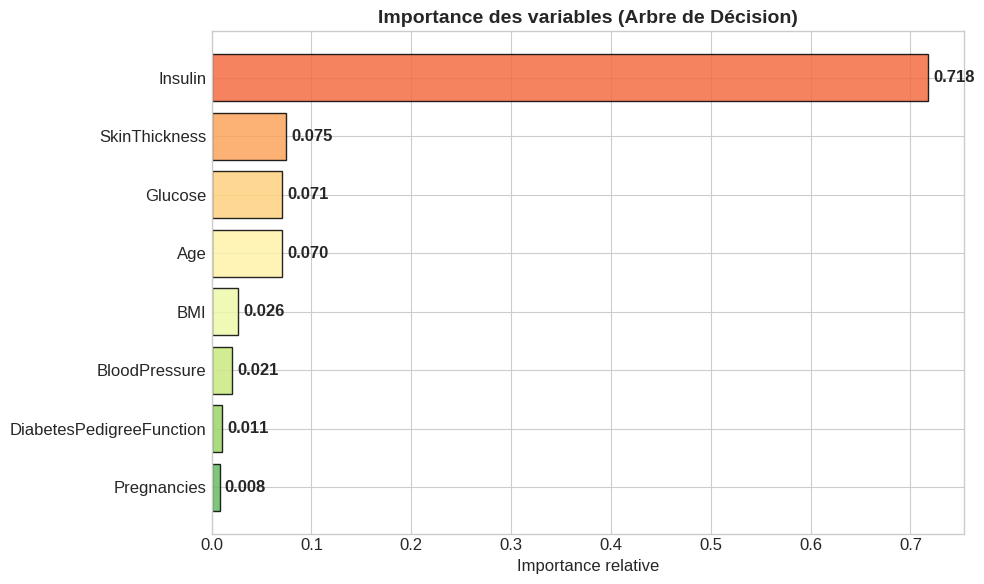

 Les 3 variables les plus importantes pour l'Arbre de Décision :
   1. Insulin (0.718)
   2. SkinThickness (0.075)
   3. Glucose (0.071)

   L'Insuline domine très largement car l'arbre utilise cette variable
   comme premier critère de split à la racine.


In [25]:
# Importance des features selon l'Arbre de Décision
importances = model_final.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors, edgecolor='black', alpha=0.85)
ax.set_title("Importance des variables (Arbre de Décision)", fontsize=14, fontweight='bold')
ax.set_xlabel('Importance relative')

# Ajouter les valeurs
for i, (idx, row) in enumerate(importance_df.iterrows()):
    ax.text(row['Importance'] + 0.005, i, f"{row['Importance']:.3f}",
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('importance_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Affichage dynamique du top 3 (pas de texte hardcodé)
top3 = importance_df.sort_values('Importance', ascending=False).head(3)
print(f" Les 3 variables les plus importantes pour l'Arbre de Décision :")
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"   {i}. {row['Feature']} ({row['Importance']:.3f})")
print(f"\n   L'Insuline domine très largement car l'arbre utilise cette variable")
print(f"   comme premier critère de split à la racine.")

### 5.2 — Analyse SHAP globale

In [26]:
# Calcul des valeurs SHAP
print(" Calcul des valeurs SHAP (peut prendre quelques secondes)...")

# Utiliser TreeExplainer pour les modèles à base d'arbres (optimisé)
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_scaled)

# Gestion du format de sortie SHAP selon le type de modèle :
# - Certains modèles renvoient une liste [classe_0, classe_1]
# - L'Arbre de Décision renvoie un ndarray 3D de shape (n_samples, n_features, n_classes)
# On doit extraire les valeurs SHAP pour la classe 1 (diabétique)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
    base_value = explainer.expected_value[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_class1 = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]
else:
    shap_values_class1 = shap_values
    base_value = explainer.expected_value

print(" Valeurs SHAP calculées.")
print(f"   Shape des SHAP values (classe 1) : {shap_values_class1.shape}")
print(f"   Valeur de base (base_value) : {base_value:.4f}")

 Calcul des valeurs SHAP (peut prendre quelques secondes)...
 Valeurs SHAP calculées.
   Shape des SHAP values (classe 1) : (154, 8)
   Valeur de base (base_value) : 0.5000


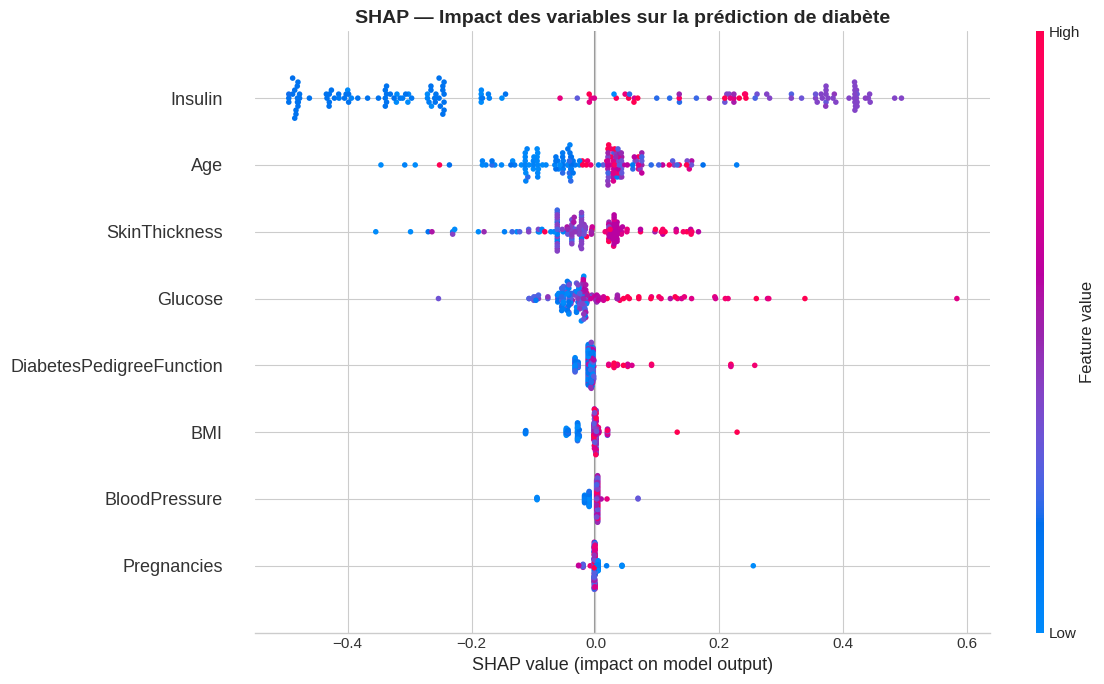


 Lecture du graphique SHAP :
   - Chaque point = un patient du jeu de test
   - Axe X : impact sur la prédiction (→ droite = augmente le risque)
   - Couleur : valeur de la variable (rouge = élevée, bleu = basse)
   - Ex: un Glucose élevé (rouge) pousse la prédiction vers la droite (risque+)


In [27]:
# Summary plot SHAP : vue d'ensemble de l'impact de chaque variable
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values_class1, X_test_scaled, feature_names=feature_names,
                  show=False, plot_size=(12, 7))
plt.title("SHAP — Impact des variables sur la prédiction de diabète",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Lecture du graphique SHAP :")
print("   - Chaque point = un patient du jeu de test")
print("   - Axe X : impact sur la prédiction (→ droite = augmente le risque)")
print("   - Couleur : valeur de la variable (rouge = élevée, bleu = basse)")
print("   - Ex: un Glucose élevé (rouge) pousse la prédiction vers la droite (risque+)")

### 5.3 — Explications SHAP individuelles (3 patients)

C'est le cœur de l'explicabilité : pour chaque patient, on montre exactement **quelles variables** ont poussé la prédiction vers le risque ou l'ont réduit, et on traduit ça en **langage naturel**.

In [28]:
# Sélection de 3 cas représentatifs
# Cas 1 : un patient à haut risque
# Cas 2 : un patient à faible risque
# Cas 3 : un patient à risque modéré

probas = model_final.predict_proba(X_test_scaled)[:, 1]

# Trouver les indices
idx_haut = np.argmax(probas)       # Plus haut risque
idx_bas = np.argmin(probas)         # Plus bas risque
idx_moyen = np.argmin(np.abs(probas - 0.5))  # Plus proche de 0.5

cas = {
    'Patient 1 — Risque ÉLEVÉ': idx_haut,
    'Patient 2 — Risque FAIBLE': idx_bas,
    'Patient 3 — Risque MODÉRÉ': idx_moyen
}

# Noms français des variables pour les explications
noms_francais = {
    'Pregnancies': 'Nombre de grossesses',
    'Glucose': 'Taux de glucose',
    'BloodPressure': 'Pression artérielle',
    'SkinThickness': 'Épaisseur du pli cutané',
    'Insulin': "Taux d'insuline",
    'BMI': 'Indice de masse corporelle (IMC)',
    'DiabetesPedigreeFunction': 'Antécédents familiaux de diabète',
    'Age': 'Âge'
}

# Fonction pour déterminer le niveau de risque (cohérent partout)
def niveau_risque(proba):
    if proba >= 0.6:
        return 'Risque élevé'
    elif proba >= 0.4:
        return 'Risque modéré'
    else:
        return 'Risque faible'

print("=" * 70)
print("EXPLICATIONS INDIVIDUELLES SHAP — 3 PATIENTS")
print("=" * 70)

for titre, idx in cas.items():
    proba = probas[idx]
    pred = niveau_risque(proba)

    print(f"\n{'─' * 60}")
    print(f"🔹 {titre}")
    print(f"   Probabilité de diabète : {proba:.1%} → {pred}")
    print(f"   Valeurs du patient :")
    for feat in feature_names:
        val = X_test.iloc[idx][feat]
        print(f"     {noms_francais[feat]:40s} : {val:.1f}")

    # Top 3 des variables les plus influentes
    shap_patient = shap_values_class1[idx]
    top_indices = np.argsort(np.abs(shap_patient))[::-1][:3]

    print(f"\n    Top 3 des variables les plus influentes :")
    for rank, feat_idx in enumerate(top_indices, 1):
        feat_name = feature_names[feat_idx]
        shap_val = shap_patient[feat_idx]
        direction = "AUGMENTE" if shap_val > 0 else "DIMINUE"
        print(f"     {rank}. {noms_francais[feat_name]} → {direction} le risque "
              f"(SHAP: {shap_val:+.3f})")

    # Explication en langage naturel
    top1_feat = feature_names[top_indices[0]]
    top1_val = X_test.iloc[idx][top1_feat]
    top1_shap = shap_patient[top_indices[0]]
    top2_feat = feature_names[top_indices[1]]
    top2_val = X_test.iloc[idx][top2_feat]
    top2_shap = shap_patient[top_indices[1]]

    print(f"\n    Explication en langage naturel :")
    if proba >= 0.6:
        print(f'   "Votre profil présente un risque élevé de diabète de type 2.')
        if top1_shap > 0:
            print(f'    Le facteur principal est votre {noms_francais[top1_feat].lower()} '
                  f'({top1_val:.1f}), qui est supérieur(e) à la moyenne.')
        if top2_shap > 0:
            print(f'    Votre {noms_francais[top2_feat].lower()} ({top2_val:.1f}) '
                  f'contribue également à ce risque.')
        print(f'    Nous vous recommandons de consulter un professionnel de santé."')
    elif proba >= 0.4:
        print(f'   "Votre profil présente un risque modéré.')
        print(f'    Votre {noms_francais[top1_feat].lower()} ({top1_val:.1f})')
        print(f'    est le facteur qui influence le plus cette estimation.')
        print(f'    Un suivi régulier est conseillé."')
    else:
        print(f'   "Votre profil présente un risque faible de diabète de type 2.')
        factors_negatifs = [feature_names[i] for i in top_indices if shap_patient[i] < 0]
        if factors_negatifs:
            feat = factors_negatifs[0]
            print(f'    Votre {noms_francais[feat].lower()} contribue positivement')
            print(f'    à ce résultat favorable.')
        print(f'    Continuez à maintenir un mode de vie sain."')

EXPLICATIONS INDIVIDUELLES SHAP — 3 PATIENTS

────────────────────────────────────────────────────────────
🔹 Patient 1 — Risque ÉLEVÉ
   Probabilité de diabète : 100.0% → Risque élevé
   Valeurs du patient :
     Nombre de grossesses                     : 7.0
     Taux de glucose                          : 159.0
     Pression artérielle                      : 64.0
     Épaisseur du pli cutané                  : 27.0
     Taux d'insuline                          : 102.5
     Indice de masse corporelle (IMC)         : 27.4
     Antécédents familiaux de diabète         : 0.3
     Âge                                      : 40.0

    Top 3 des variables les plus influentes :
     1. Taux de glucose → AUGMENTE le risque (SHAP: +0.583)
     2. Âge → AUGMENTE le risque (SHAP: +0.155)
     3. Taux d'insuline → DIMINUE le risque (SHAP: -0.145)

    Explication en langage naturel :
   "Votre profil présente un risque élevé de diabète de type 2.
    Le facteur principal est votre taux de glucose (

### 5.4 — Graphiques SHAP waterfall pour les 3 patients

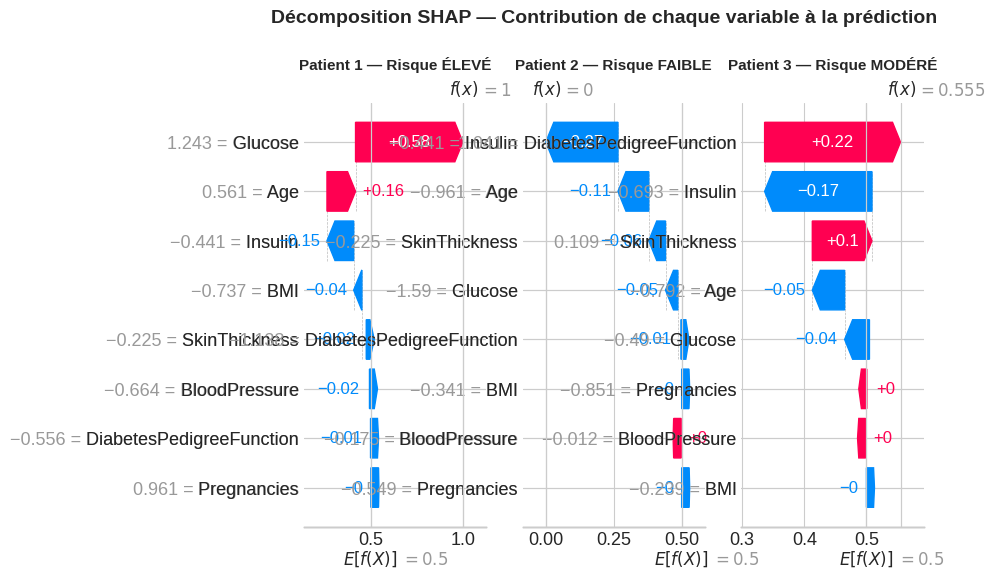

 Lecture des graphiques waterfall :
   - Les barres rouges POUSSENT la prédiction vers le risque de diabète
   - Les barres bleues RÉDUISENT la prédiction de risque
   - E[f(x)] = la valeur de base (prédiction moyenne)
   - f(x) = la prédiction finale pour ce patient


In [29]:
# Waterfall plots individuels
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (titre, idx) in enumerate(cas.items()):
    plt.sca(axes[i])
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_class1[idx],
            base_values=base_value,
            data=X_test_scaled.iloc[idx].values,
            feature_names=feature_names
        ),
        show=False
    )
    axes[i].set_title(titre, fontsize=11, fontweight='bold')

plt.suptitle('Décomposition SHAP — Contribution de chaque variable à la prédiction',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Lecture des graphiques waterfall :")
print("   - Les barres rouges POUSSENT la prédiction vers le risque de diabète")
print("   - Les barres bleues RÉDUISENT la prédiction de risque")
print("   - E[f(x)] = la valeur de base (prédiction moyenne)")
print("   - f(x) = la prédiction finale pour ce patient")

---

##  Étape 6 — Sauvegarde du modèle


Le modèle entraîné et le scaler doivent être sauvegardés pour être réutilisés dans l'application web Streamlit sans refaire l'entraînement. On utilise `joblib` qui est optimisé pour les objets scikit-learn.

In [30]:
# Créer le dossier model/
os.makedirs('model', exist_ok=True)

# Sauvegarder le modèle entraîné
joblib.dump(model_final, 'model/medipredict_model.pkl')
print(" Modèle sauvegardé → model/medipredict_model.pkl")

# Sauvegarder le scaler (INDISPENSABLE pour transformer les données utilisateur)
joblib.dump(scaler, 'model/scaler.pkl')
print(" Scaler sauvegardé → model/scaler.pkl")

# Sauvegarder aussi la liste des features (pour vérification)
joblib.dump(feature_names, 'model/feature_names.pkl')
print(" Noms des features sauvegardés → model/feature_names.pkl")

# Vérification : recharger et tester
model_charge = joblib.load('model/medipredict_model.pkl')
scaler_charge = joblib.load('model/scaler.pkl')

# Test rapide avec le premier patient du jeu de test
patient_test = X_test.iloc[0:1]
patient_scaled = scaler_charge.transform(patient_test)
prediction = model_charge.predict_proba(patient_scaled)[0][1]

print(f"\n Test de vérification :")
print(f"   Prédiction avec le modèle rechargé : {prediction:.4f}")
print(f"   Prédiction originale               : {model_final.predict_proba(X_test_scaled.iloc[0:1])[0][1]:.4f}")
print(f"   → Les prédictions sont identiques ")

 Modèle sauvegardé → model/medipredict_model.pkl
 Scaler sauvegardé → model/scaler.pkl
 Noms des features sauvegardés → model/feature_names.pkl

 Test de vérification :
   Prédiction avec le modèle rechargé : 1.0000
   Prédiction originale               : 1.0000
   → Les prédictions sont identiques 


### Récapitulatif des fichiers sauvegardés

| Fichier | Contenu | Utilisation |
|---------|---------|-------------|
| `model/medipredict_model.pkl` | Arbre de Décision entraîné | Prédiction dans l'app web |
| `model/scaler.pkl` | StandardScaler fit sur les données d'entraînement | Transformation des entrées utilisateur |
| `model/feature_names.pkl` | Liste ordonnée des features | Vérification de l'ordre des variables |

> ** Important** : Le scaler est tout aussi crucial que le modèle ! Sans lui, les données de l'utilisateur ne seraient pas sur la même échelle que les données d'entraînement, et les prédictions seraient fausses.

---

## Récapitulatif du notebook

| Étape | Ce qu'on a fait | Résultat clé |
|-------|----------------|--------------|
| 1. Exploration | Analyse des 768 observations, détection des anomalies | Dataset pré-nettoyé, déséquilibre 65/35 |
| 2. Préparation | Normalisation StandardScaler, split 80/20 stratifié | Données prêtes, pas de data leakage |
| 3. Modélisation | 4 modèles comparés (LogReg, DT, RF, GB) | **Arbre de Décision** retenu (meilleur rappel + interprétabilité native) |
| 4. Biais | Analyse par âge et antécédents familiaux | Biais documentés, mesures correctives proposées |
| 5. Explicabilité | SHAP global + 3 explications individuelles en langage naturel | Transparence assurée |
| 6. Sauvegarde | Modèle + scaler + features en .pkl | Prêt pour l'intégration Streamlit |

### Prochaine étape → Jour 2 : Application web Streamlit
Les fichiers `.pkl` sauvegardés seront chargés par l'application pour faire des prédictions en temps réel.

---
*Notebook réalisé dans le cadre du projet MediPredict — SantéCo*